# Cars 4 You: Homework Group 21

## Introduction to the Project

Cars 4 You is an online car-resale platform that purchases used cars from private sellers.  
Currently, every car submitted on the platform needs to go through a physical inspection by a mechanic before a price offer can be made. As the company grows, this manual evaluation process has become a bottleneck, resulting in long waiting times and causing potential customers to drop out and look for alternatives.

To streamline the process, Cars 4 You has provided historical car inspection and purchase records.  
Using this dataset, our goal is to **build a machine learning model capable of predicting a car’s price based solely on attributes provided by the seller**, without requiring a mechanic to evaluate the vehicle first.

### Dataset Overview

The dataset contains several attributes that describe each car at the time of registration.  
These include characteristics such as brand, mileage, year of registration, engine size, previous owners, and more.

Below is the metadata table describing each attribute in the dataset:

<p align="center">
  <img src="images/Metadata.png" alt="Cars 4 You Dataset Metadata" width="650">
</p>

### Project Objectives

- Perform exploratory data analysis to understand the dataset and identify key variables impacting car price.
- Clean and preprocess the data (handle missing values, outliers, feature inconsistencies).
- Build and benchmark multiple regression models using a well-defined evaluation strategy.
- Optimize the best-performing model through feature engineering and hyperparameter tuning.
- Deploy the final model to generate predictions for unseen data (Kaggle competition test set).

---

**Team Members:**
- Oliver Kain, 20250401, 20250401@novaims.unl.pt  
- João Ramos, 20250413, 20250413@novaims.unl.pt  
- Gonçalo Castro, 20250415, 20250415@novaims.unl.pt  
- Mehmet Karaca, 20250344, 20250344@novaims.unl.pt

**Deliverable:** Data exploration, preprocessing, feature selection, and first benchmarks  
**Deadline:** 03.11.2025 (17:59)


# Table of Contents

Take this as an example for a Table of Contents for your notebook.
We have to fix all the names and sections according to what we actually do in the notebook.

<a class="anchor" id="top"></a>

** **

1. [Importing Libraries & Data](#1.-Importing-Libraries-&-Data) <br>
   

    
2. [Data Access & Loading](#2.-Data-Access-&-Loading) <br>

3. [Schema Overview](#3.-Schema-Overview) <br>
   
4. [Descriptive Statistics (Numeric & Categorical)](#4.-Descriptive-Statistics-(Numeric-&-Categorical)) <br>

5. [Missing Values](#5.-Missing-Values) <br>

6. [Distributions & Potential Outliers](#6.-Distributions-&-Potential-Outliers) <br>

7. [Categorical Overview](#7.-Categorical-Overview) <br>

8. [Correlation Analysis (Numerical)](#8.-Correlation-Analysis-(Numerical)) <br>

9.  [Bivariate Relations w.r.t. Target (`price`)](#9.-Bivariate-Relations-w.r.t.-Target-(`price`)) <br>

10. [Data Quality Checks](#10.-Data-Quality-Checks) <br>

11. [Key Findings for the next step](#11.-Key-Findings-for-the-next-step) <br>
   

## 00 — Data Exploration (Cars 4 You)

> **Scope:** Pure EDA. No cleaning and no modeling in this notebook.  
> The goal here is to explore the data, not transform it.

### Purpose of this Notebook

Before building any predictive model, we need to understand the dataset provided by Cars 4 You.  
This notebook focuses only on Exploratory Data Analysis (EDA). The objective is to examine the data to uncover patterns, detect anomalies, and validate assumptions.

More specifically, this notebook aims to:

- Understand the structure of the dataset: columns, data types, missing values, duplicates.
- Assess data quality and identify potential data issues: inconsistencies, incorrect values, outliers.
- Explore distributions of variables related to car characteristics, for example mileage, year, and engine size.
- Analyze relationships between features and the target variable (price), to guide feature selection later.
- Formulate initial hypotheses about what makes a car more expensive or cheaper.
- Document insights that will influence preprocessing and modeling decisions in the next phase.



## 1. Importing Libraries & Data

In [1]:
import os, re, math, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
pd.set_option("mode.copy_on_write", True)

# Plot Style
plt.style.use("seaborn-v0_8")

RANDOM_STATE = 42  # for reproducibility of any sampling


## 2. Data Access & Loading

In [2]:
# Load the data paths
data_dir = "../data/"

# Load the raw data into a pandas dataframe
df = pd.read_csv(os.path.join(data_dir, "train.csv"))

## 3. Schema Overview

In [3]:
# Schema overview: data types, missing values, and unique counts for each column.
print("Shape:", df.shape)
display(pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum().values,
    "missing_%": (df.isna().sum().values/len(df)*100).round(2),
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns]
}))
df.info()

Shape: (75973, 14)


,column,dtype,n_missing,missing_%,n_unique
carID,carID,int64,0,0.00,75973
Brand,Brand,object,1521,2.00,72
model,model,object,1517,2.00,735
year,year,float64,1491,1.96,44
price,price,int64,0,0.00,11048
transmission,transmission,object,1522,2.00,40
mileage,mileage,float64,1463,1.93,34808
fuelType,fuelType,object,1511,1.99,34
tax,tax,float64,7904,10.40,65
mpg,mpg,float64,7926,10.43,217


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


## 4. Descriptive Statistics (Numeric & Categorical)

In [5]:
# Here we're displaying the descriptive statistics for numerical features
display(df.describe().T)

# Here we're displaying the descriptive statistics for categorical features
display(df.describe(include='object').T)

,count,mean,std,min,25%,50%,75%,max
carID,75973.0,37986.000000,21931.660338,0.000000,18993.00,37986.0,56979.0,75972.000000
year,74482.0,2017.096611,2.208704,1970.000000,2016.00,2017.0,2019.0,2024.121759
price,75973.0,16881.889553,9736.926322,450.000000,10200.00,14699.0,20950.0,159999.000000
mileage,74510.0,23004.184088,22129.788366,-58540.574478,7423.25,17300.0,32427.5,323000.000000
tax,68069.0,120.329078,65.521176,-91.121630,125.00,145.0,145.0,580.000000
mpg,68047.0,55.152666,16.497837,-43.421768,46.30,54.3,62.8,470.800000
engineSize,74457.0,1.660136,0.573462,-0.103493,1.20,1.6,2.0,6.600000
paintQuality%,74449.0,64.590667,21.021065,1.638913,47.00,65.0,82.0,125.594308
previousOwners,74423.0,1.994580,1.472981,-2.345650,1.00,2.0,3.0,6.258371
hasDamage,74425.0,0.000000,0.000000,0.000000,0.00,0.0,0.0,0.000000


,count,unique,top,freq
Brand,74452,72,Ford,14808
model,74456,735,Focus,6353
transmission,74451,40,Manual,38050
fuelType,74462,34,Petrol,37995


## 5. Missing Values

In [6]:
# Here we're displaying the features sorted by number of missing values (from highest to lowest).
# This will help us identify which columns may require cleaning and/or imputation during preprocessing.
miss = df.isna().sum().sort_values(ascending=False)
miss = miss[miss>0]
if len(miss):
    display(miss.to_frame("n_missing").assign(missing_pct=lambda d: (d['n_missing']/len(df)*100).round(2)))
else:
    print("No missing values detected.")

,n_missing,missing_pct
mpg,7926,10.43
tax,7904,10.40
previousOwners,1550,2.04
hasDamage,1548,2.04
paintQuality%,1524,2.01
transmission,1522,2.00
Brand,1521,2.00
model,1517,2.00
engineSize,1516,2.00
fuelType,1511,1.99


**Here we can see that `mpg` (miles per gallon) and `tax` are the features with the highest number of missing values**

## 6. Distributions & Potential Outliers

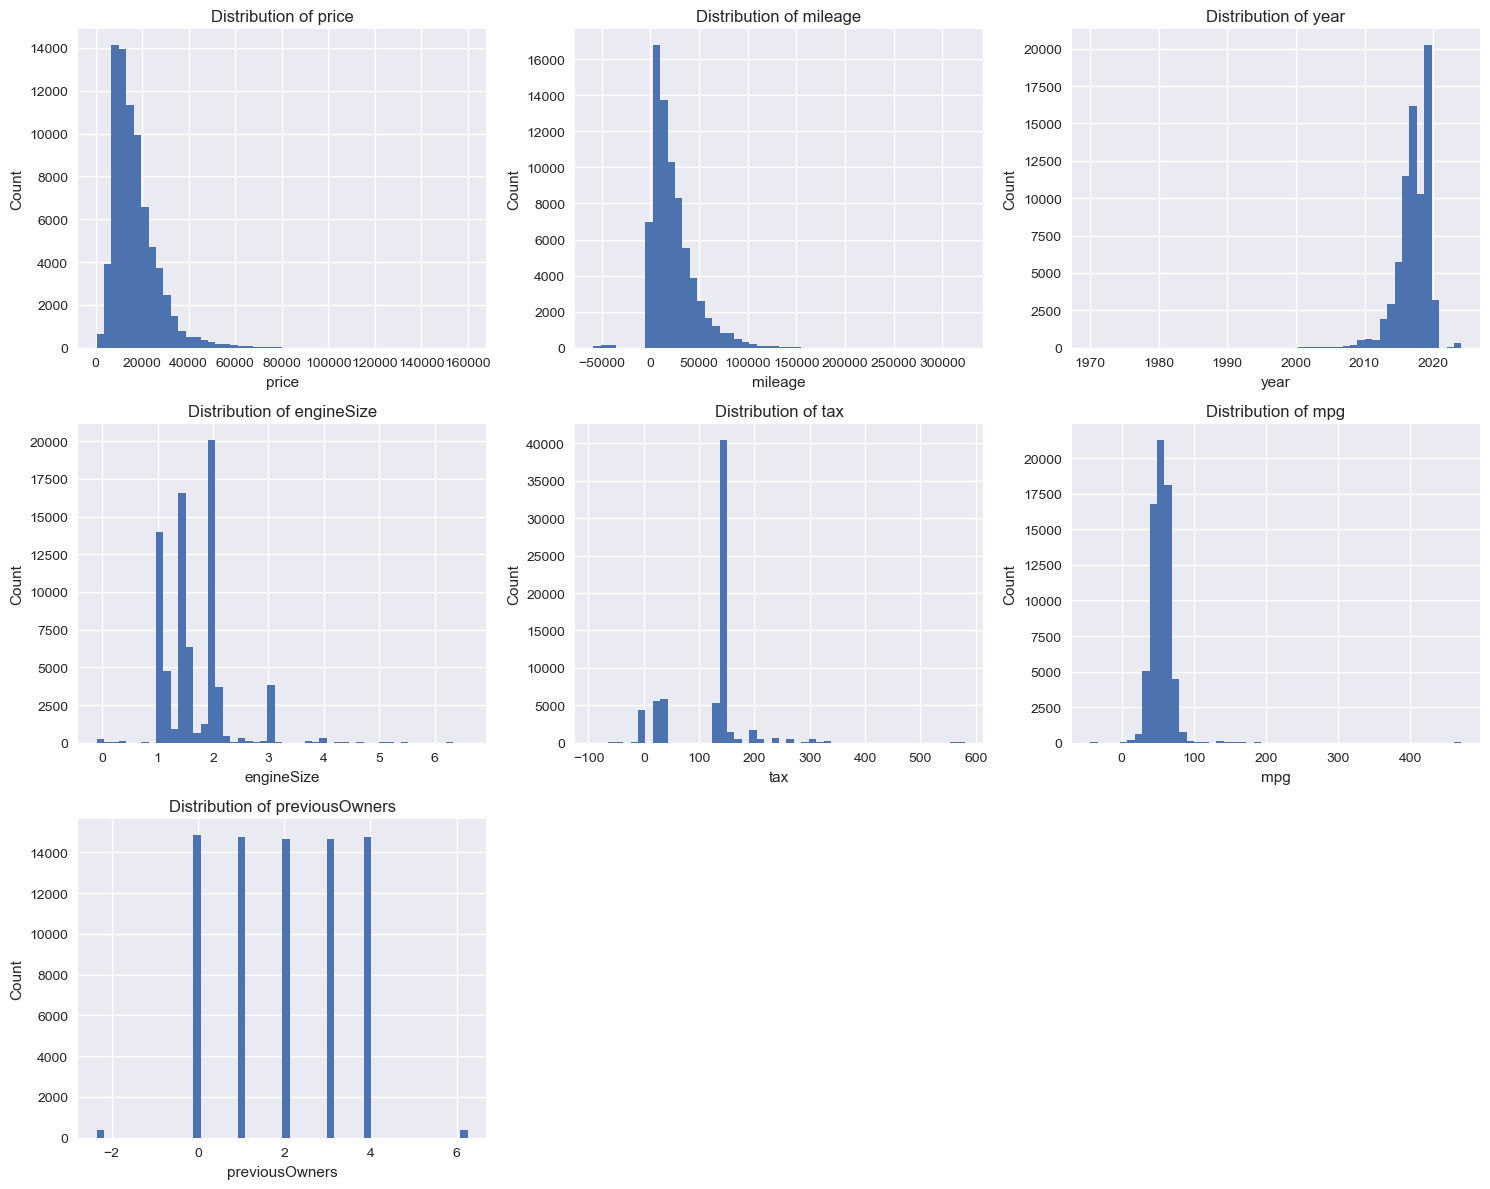

In [7]:
# Pick common numeric columns if present
num_candidates = [c for c in ['price', 'mileage', 'year', 'engineSize', 'tax', 'mpg', 'previousOwners'] if c in df.columns]

# Determine grid size (3 columns per row)
n_cols = 3
n_rows = (len(num_candidates) + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()  # flatten to iterate easily
#Iterate over each one of the numeric collums and display a histogram where the Y is the count
# And the X is the respective value of each numeric collum
for i, col in enumerate(num_candidates):
    ax = axes[i]
    df[col].dropna().hist(bins=50, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


From the previous histograms, we can conclude that the dataset contains the following issues:

- **Prices** with values equal to `0` (free listings).
- **Years** recorded **after 2020**, even though the limit should be 2020.
- **Engine sizes** with a value of `0`.
- **Negative values** found in the following columns:
  - `previousOwners`
  - `tax`
  - `mpg`
  - `mileage`


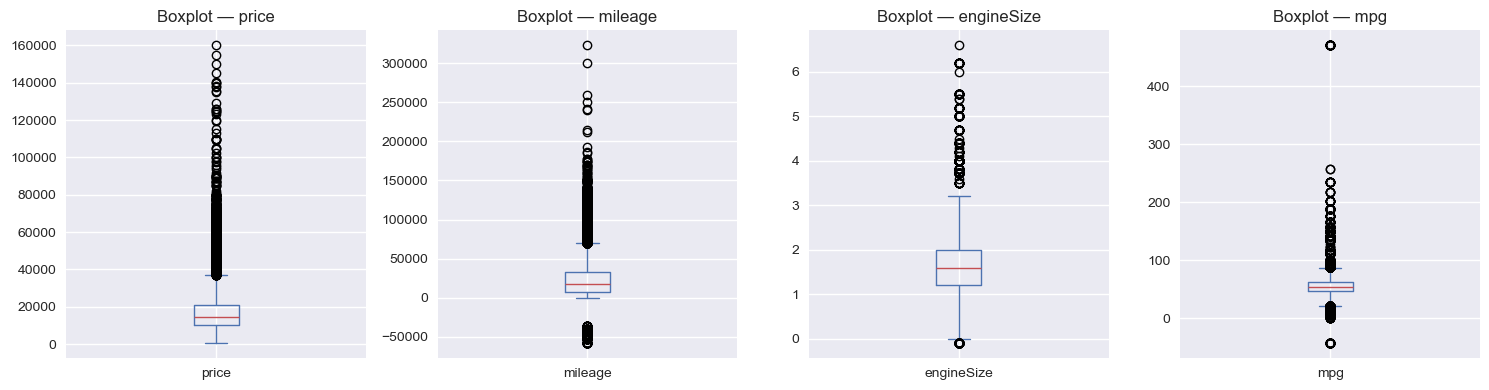

In [8]:
# Select numeric columns available
num_candidates = [c for c in ['price', 'mileage', 'engineSize', 'mpg'] if c in df.columns]

# Set grid layout (4 columns per row)
n_cols = 4
n_rows = (len(num_candidates) + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_candidates):
    ax = axes[i]
    df[[col]].dropna().plot(kind="box", ax=ax, title=f"Boxplot — {col}")
    ax.set_xlabel("")  # cleaner look

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Several numerical features, including mileage and mpg, contain outliers on both the lower and upper ends of the distribution. However, the majority of extreme values appear on the higher end, suggesting the presence of unusually large measurements.**

## 7. Categorical Overview

In [9]:
# Identify all categorical columns (dtype 'object') in the DataFrame
cat_cols = [c for c in df.columns if df[c].dtype=='object']

# Initialize a list to store summary DataFrames for each categorical column
summary = []

# Loop over each categorical column
for c in cat_cols:
    # Get value counts for the column, including NaN, limited to the top 15 categories
    vc = df[c].value_counts(dropna=False).head(15)
    
    # Create a DataFrame with the category names and counts, add the column name
    summary.append(pd.DataFrame({
        "category": vc.index.astype(str),  # Ensure categories are strings
        "count": vc.values
    }).assign(column=c))

# If there are any categorical columns, concatenate their summaries and display the first 50 rows of the summary DataFrame
if summary:
    summary_df = pd.concat(summary, ignore_index=True)
    display(summary_df.head(50))
else:
    # If not inform the user if no categorical columns were found
    print("No categorical columns detected.")

,category,count,column
0,Ford,14808,Brand
1,Mercedes,10754,Brand
2,VW,9780,Brand
3,Opel,8645,Brand
4,BMW,6968,Brand
5,Audi,6749,Brand
6,Toyota,4289,Brand
7,Skoda,3973,Brand
8,Hyundai,3066,Brand
9,nan,1521,Brand


**By observing the top categories for each categorical column, we can identify likely invalid or misspelled entries.  
For example, in `Brand` we see `'ord'` instead of `'Ford'` and `'ercedes'` instead of `'Mercedes'`.  
Similar issues may exist in `Model`, `Transmission`, or `FuelType`, indicating a need for data cleaning.**

## 8. Correlation Analysis (Numerical)

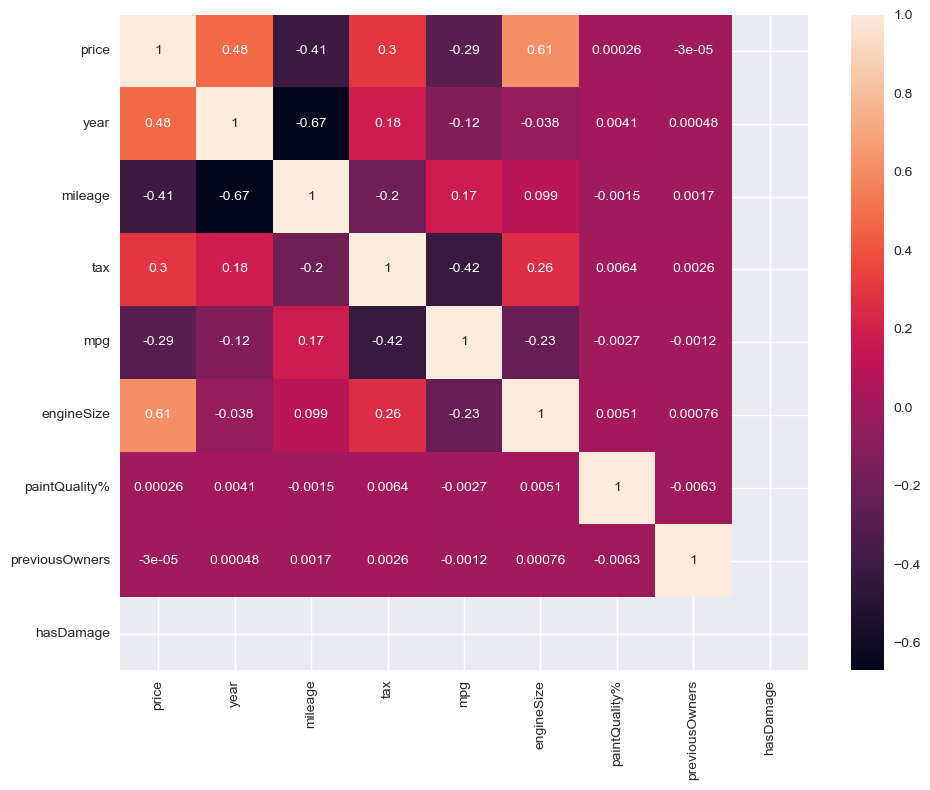

In [5]:
# Generate and display a correlation heatmap for numeric columns in the DataFrame

fig = plt.figure(figsize=(10, 8))

# Identify all numeric columns, excluding 'carID'

num_cols = df.select_dtypes(include=['number']).columns.drop('carID').tolist()

# Proceed only if there are at least two numeric columns

if len(num_cols) > 1:
# Compute the correlation matrix for numeric columns
corr = df[num_cols].corr(numeric_only=True)

if 'price' in corr.columns:
    # Reorder columns/rows so price appears first in the correlation matrix
    cols = ['price'] + [col for col in corr.columns if col != 'price']
    corr = corr.loc[cols, cols]

    # heatmap of the correlation matrix
    ax = sns.heatmap(data=corr, annot=True)
else:
    print("Not enough numeric columns for correlation matrix.")


# display the heatmap
plt.show()


- **Strong positive correlation** between `engineSize` and `price` (**61%**).  
- **Strong negative correlation** between `year` and `mileage` (**–67%**).  
- **Moderate positive correlation** between `price` and `year` (**48%**).  
- **Moderate negative correlations** between:  
  - `price` and `mileage` (**–41%**)  
  - `tax` and `mpg` (**–42%**)


## 9. Bivariate Relations w.r.t. Target (`price`)

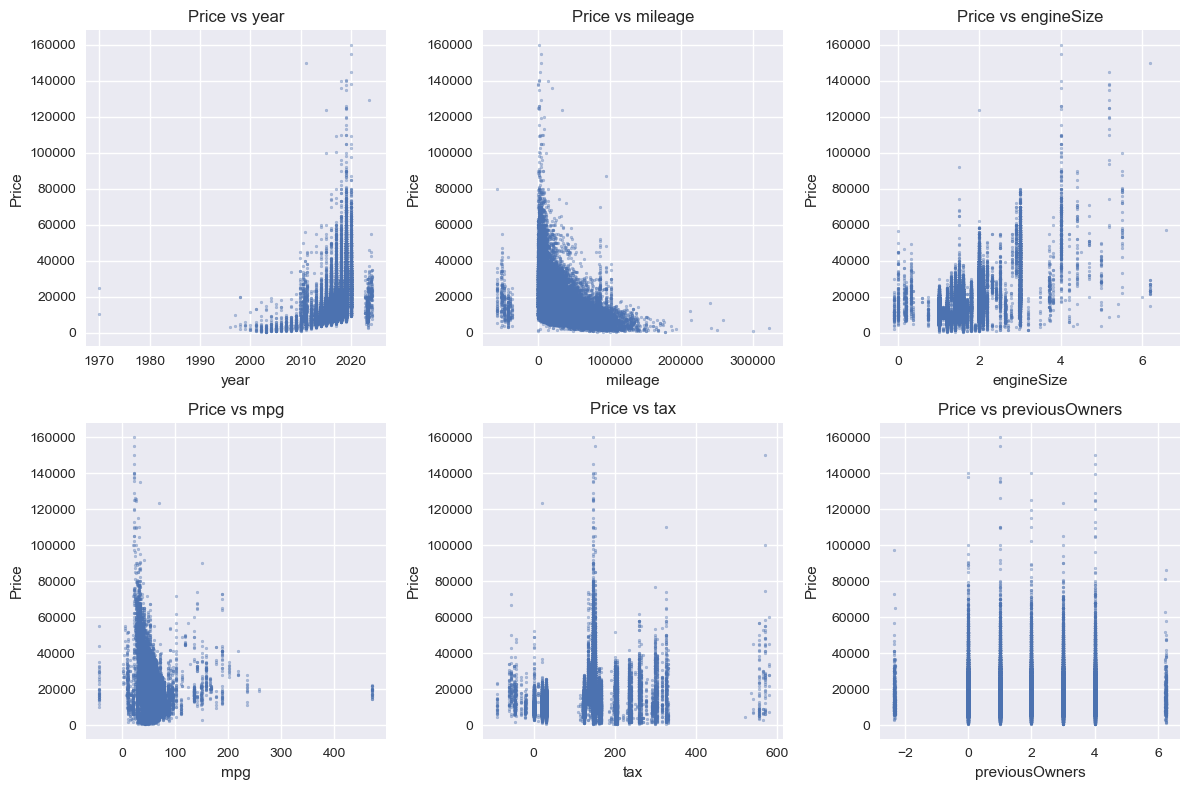

In [7]:
# Generate scatter plots showing the relationship between car price and selected numeric predictors
# Select numeric predictor columns that exist in the DataFrame

num_candidates = [c for c in ['year', 'mileage', 'engineSize', 'mpg', 'tax', 'previousOwners'] if c in df.columns]

# Define grid layout for subplots (3 columns per row)

n_cols = 3

# ceiling division to fit all plots
n_rows = (len(num_candidates) + n_cols - 1) // n_cols

# Create figure and axes for subplots

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()  # Flatten axes array for easy iteration

# Loop through each numeric column and plot Price vs that column

for i, col in enumerate(num_candidates):
    ax = axes[i]
    # Create a scatter plot for the numeric variable against price
    ax.scatter(df[col], df['price'], s=4, alpha=0.4)
    ax.set_title(f"Price vs {col}")  # Set subplot title
    ax.set_xlabel(col)               # Label x-axis with column name
    ax.set_ylabel("Price")           # Label y-axis with 'Price'

# Hide any unused subplot axes if there are fewer plots than grid slots

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout spacing and display all scatter plots

plt.tight_layout()
plt.show()


In [8]:
# Display summary statistics of car prices (count, mean, median) by top categories such as Brand, fuelType, model, and hasDamage

# Loop through each categorical column of interest, only if it exists in the DataFrame

for cat in [c for c in ['Brand', 'fuelType', 'model', 'hasDamage'] if c in df.columns]:
# Identify the top 10 most frequent categories for the given column
    top = df[cat].value_counts().head(10).index

    # Filter DataFrame to include only rows belonging to these top categories
    # Group by category and calculate count, mean, and median of price
    # Sort the values descending
    gdf = (
        df[df[cat].isin(top)]
        .groupby(cat)['price']
        .agg(['count', 'mean', 'median'])
        .sort_values('mean', ascending=False)
    )

    # Display a formatted header and the resulting DataFrame
    print(f"== {cat} — top 10 by frequency ==")
display(gdf)



== Brand — top 10 by frequency ==
== fuelType — top 10 by frequency ==
== model — top 10 by frequency ==
== hasDamage — top 10 by frequency ==


,count,mean,median
hasDamage,,,
0.0,74425,16883.212509,14698.0


## 10. Data Quality Checks

In [16]:
# Perform data integrity and validation checks on key columns and numeric fields
# Check for duplicate records using likely ID columns, if present

id_cols = [c for c in ['carID', 'id'] if c in df.columns]
if id_cols:
# Loop through each possible ID column and count duplicates
    for cid in id_cols:
        dup_n = df.duplicated(subset=[cid]).sum()
        print(f"Duplicates by {cid}: {dup_n}")
else:
# Inform user if no ID column was found
    print("No explicit ID column found; skipping duplicate check by ID.")

# Check numeric columns for negative values and count occurrences
print((df.select_dtypes(include=['number']) < 0).sum())

# Calculate percentage of negative values relative to total number of rows
print(((df.select_dtypes(include=['number']) < 0).sum() / len(df)) * 100)

# Identify cars with a 'year' later than 2020 — such records should not exist
print("Cars with year greater than 2020: " + str((df['year'] > 2020).sum()))

# Validate that paint quality percentages do not exceed 100%
print("Cars with better quality than 100 percent: " + str((df['paintQuality%'] > 100).sum()))

# Check for cars with engine sizes outside the realistic range (0.8 to 6.2)
print("Cars with unusual engine size: " + str(((df['engineSize'] > 6.2) | (df['engineSize'] < 0.8)).sum()))

# Define conditions for unrealistic mpg values based on fuel type
unusual_mpg_mask = (
((df['mpg'] > 140) & (df["fuelType"] == "electric")) |
((df['mpg'] < 80) & (df["fuelType"] == "electric")) |
((df['mpg'] > 70) & (df["fuelType"] == "hybrid")) |
((df['mpg'] < 30) & (df["fuelType"] == "hybrid")) |
((df['mpg'] > 70) & (df["fuelType"] != "hybrid") & (df["fuelType"] != "electric")) |
((df['mpg'] < 10) & (df["fuelType"] != "hybrid") & (df["fuelType"] != "electric"))
)

# Count cars that meet the unusual mpg conditions
print("Cars with unusual mpg: ", unusual_mpg_mask.sum())

# Check integer-type columns ('year', 'previousOwners') for non-integer values
int_cols = ['year', 'previousOwners']
for col in int_cols:
# Identify values that are not integers
    non_int_mask = (df[col] % 1 != 0)
    count_non_int = non_int_mask.sum()
    print(f"Float numbers in {col}: {count_non_int} non-integer values")


Duplicates by carID: 0
carID               0
year                0
price               0
mileage           369
tax               378
mpg                36
engineSize         84
paintQuality%       0
previousOwners    371
hasDamage           0
dtype: int64
carID             0.000000
year              0.000000
price             0.000000
mileage           0.485699
tax               0.497545
mpg               0.047385
engineSize        0.110566
paintQuality%     0.000000
previousOwners    0.488331
hasDamage         0.000000
dtype: float64
Cars with year greater than 2020: 358
Cars with better quality than 100 percent: 367
Cars with unusual engine size: 575
Cars with unusual mpg:  6075
Float numbers in year: 2214 non-integer values
Float numbers in previousOwners: 2284 non-integer values


Based on the previous information, we can conclude the following:

#### Duplicates
- *High number of duplicates* in `previousOwners`, `mileage`, and `tax`.  
- *Some duplicates* in `mpg` and `engineSize`.  
- *No duplicates* in `hasDamage`, `paintQuality`, `price`, `year`, and `carID`.

#### Negative Values
- *High percentage of negative values* in `previousOwners`, `mileage`, and `tax`.  
- *Low percentage of negative values* in `mpg` and `engineSize`.  
- *No negative values* in `hasDamage`, `paintQuality`, `price`, `year`, and `carID`.


In [17]:
# Check for non-integer year values and compare their average mileage against integer year values

# Display frequency of all 'year' values, including missing entries
print(df["year"].value_counts(dropna=False))

# Compute mean mileage for each distinct year value
mean_mileage = df.groupby("year")['mileage'].mean().reset_index()

# Separate years into non-integer and integer groups based on remainder check
float_years = mean_mileage[mean_mileage['year'] % 1 != 0]
int_years = mean_mileage[mean_mileage['year'] % 1 == 0]

# Display non-integer years and their corresponding mean mileage
print(float_years)

# Display integer years and their corresponding mean mileage
print(int_years)


year
2019.000000    20271
2017.000000    16146
2016.000000    11502
2018.000000    10304
2015.000000     5733
2020.000000     3174
2014.000000     2930
2013.000000     1902
NaN             1491
2012.000000      478
2011.000000      318
2010.000000      241
2009.000000      228
2008.000000      158
2007.000000      123
2010.676968       82
2023.116964       77
2005.000000       64
2006.000000       62
2010.746403       58
2023.977311       55
2023.389822       53
2011.210853       50
2010.565009       47
2023.267989       43
2023.605276       39
2009.816757       37
2010.371546       35
2004.000000       35
2024.121759       34
2003.000000       29
2023.367078       26
2002.000000       25
2012.695740       21
2010.268635       20
2022.696685       19
2011.111188       15
2001.000000       15
2022.878006       12
2000.000000        6
1998.000000        5
1999.000000        5
1970.000000        2
1997.000000        2
1996.000000        1
Name: count, dtype: int64
           year       mi

tax_sign
negative    -45.78061
positive    145.00000
Name: tax, dtype: float64


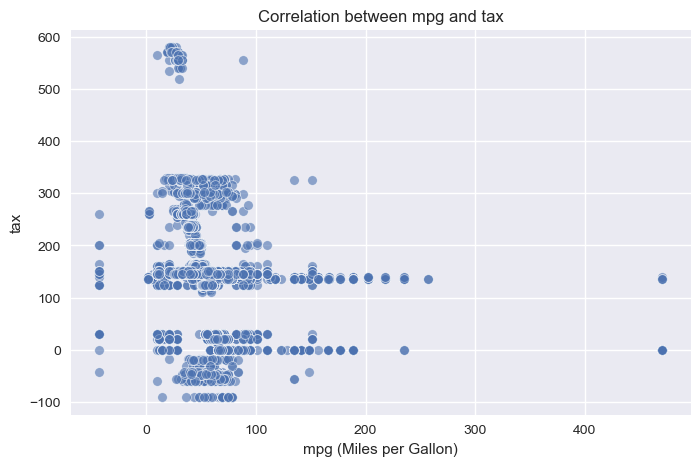

In [20]:
# Compare the median of negative and positive tax values to determine if negative entries are likely sign errors

# classifying tax values as 'negative' or 'positive'
avg_tax_by_year = (
df.assign(tax_sign=np.where(df['tax'] < 0, 'negative', 'positive'))
.groupby(['tax_sign'])['tax']
.median()
)

# Print the median tax value for each sign group
print(avg_tax_by_year)

# Plot a scatter plot to visualize the relationship between mpg and tax
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='mpg', y='tax', alpha=0.6)
plt.title('Correlation between mpg and tax')
plt.xlabel('mpg (Miles per Gallon)')
plt.ylabel('tax')
plt.show()


**high correlation between negative `tax` (0 to 100) and `mpg` on 0 to 100**

In [12]:
# Compare the mean mileage of negative and positive values for each year to identify potential sign errors or data inconsistencies

# Create a new column that labels each mileage value as 'negative' or 'positive' based on its sign

avg_mileage_by_year = (
df.assign(mileage_sign=np.where(df['mileage'] < 0, 'negative', 'positive'))
# Group data by year and mileage sign, then calculate the mean mileage for each group
.groupby(['year', 'mileage_sign'])['mileage']
.mean()
# Reshape the result so each sign becomes a column
.unstack()
)

# Display the resulting table comparing mean negative and positive mileage per year
print(avg_mileage_by_year)


mileage_sign      negative      positive
year                                    
1970.000000            NaN  25678.500000
1996.000000            NaN  50000.000000
1997.000000            NaN  62500.000000
1998.000000            NaN  67147.750000
1999.000000            NaN  61446.200000
2000.000000            NaN  66589.200000
2001.000000            NaN  65864.466667
2002.000000  -52618.457894  83498.181818
2003.000000            NaN  89402.894139
2004.000000  -58540.574478  93506.562500
2005.000000            NaN  92521.210736
2006.000000            NaN  87987.370968
2007.000000  -50755.210230  85368.866088
2008.000000  -42707.564215  90949.845161
2009.000000  -42707.564215  82456.742820
2009.816757            NaN  31150.891892
2010.000000  -48568.891663  81670.193966
2010.268635            NaN  24029.684211
2010.371546            NaN  18839.714286
2010.565009            NaN  23144.383813
2010.676968  -42650.453719  20625.012658
2010.746403            NaN  19030.912281
2011.000000  -47

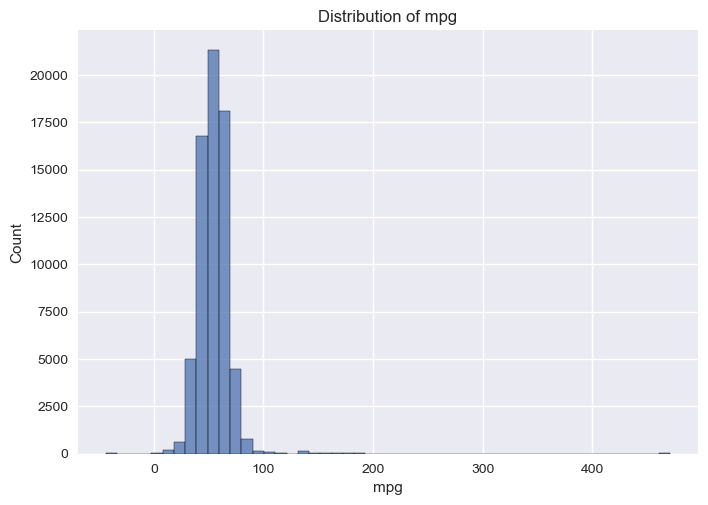

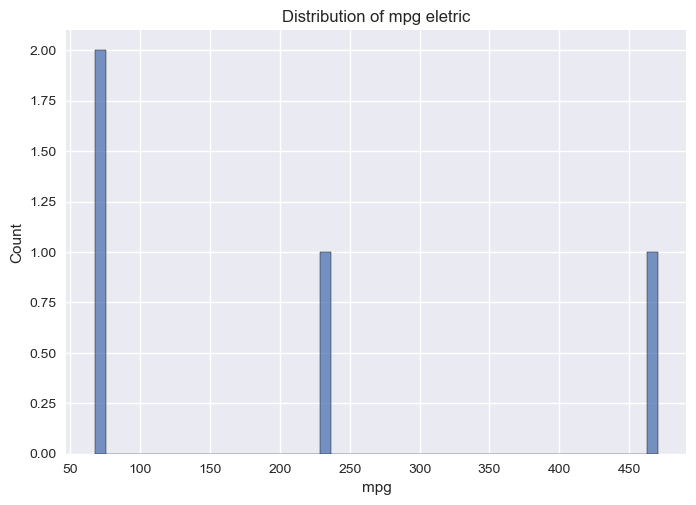

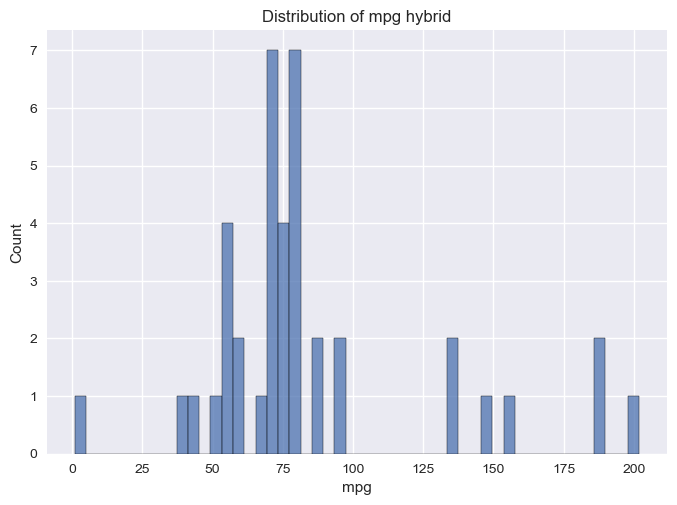

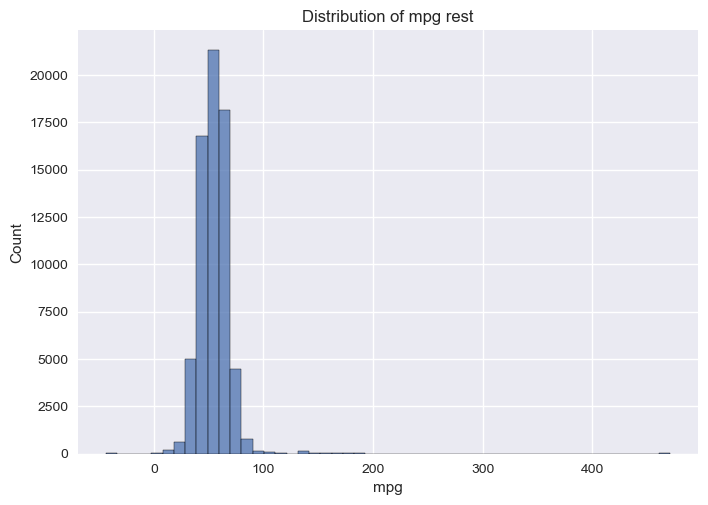

In [24]:
# now we look at the mpg histogram
sns.histplot(data=df, x='mpg', bins=50)
plt.title('Distribution of mpg')
plt.show()
sns.histplot(data=df[df["fuelType"] == "Electric"], x='mpg', bins=50)
plt.title('Distribution of mpg eletric')
plt.show()
sns.histplot(data=df[df["fuelType"] == "hybrid"], x='mpg', bins=50)
plt.title('Distribution of mpg hybrid')
plt.show()
sns.histplot(data=df[(df["fuelType"] != "hybrid")& (df["fuelType"] != "Electric")], x='mpg', bins=50)
plt.title('Distribution of mpg rest')
plt.show()

The distribution of **`mpg`** shows three distinct patterns.
For the **eletric vehicles** there are only 3 values of `mpg`
For **hybrid vehicles**, the values are well distributed across the range.  
For the **remaining vehicles and distribution of `mpg`**, most values are concentrated between **40 and 80 `mpg`**.  
Additionally, there is a **notable upper outlier** with a significantly high `mpg` value.


## 11. Key Findings for the next step

**The purpose of this notebook is to identify key insights within our dataset, such as outliers, missing values, correlations, and duplicates. Based on these findings, we will proceed to clean the data by removing negative values, handling missing entries appropriately, and addressing outliers to ensure data quality and reliability.**